To demonstrate the ``CPPPlot().feature_map()`` method, we first load the example ``DOM_GSEC`` dataset and its respective features (see [Breimann25a]_):


In [1]:
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False

df_seq = aa.load_dataset(name="DOM_GSEC")
df_feat = aa.load_features(name="DOM_GSEC")
df_feat = df_feat.sort_values(by="feat_importance", ascending=False).reset_index(drop=True)
aa.display_df(df_feat, show_shape=True, n_rows=7)

DataFrame shape: (150, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...,11)-LIFS790102",Conformation,β-strand,β-strand,"Conformational ...n-Sander, 1979)",0.189000,0.125674,0.125674,0.183876,0.218813,0.000001,0.000039,"28,29",4.729200,4.776785
2,"TMD_C_JMD_C-Seg...2,3)-CHOP780212",Conformation,β-sheet (C-term),β-turn (1st residue),"Frequency of th...-Fasman, 1978b)",0.199000,0.065983,-0.065983,0.087814,0.105835,0.000000,0.000016,"27,28,29,30,31,32,33",4.106000,5.236574
3,"TMD_C_JMD_C-Seg...3,4)-HUTJ700102",Energy,Entropy,Entropy,"Absolute entrop...Hutchens, 1970)",0.229000,0.098224,0.098224,0.106865,0.124608,0.000000,0.000001,"31,32,33,34,35",3.111200,3.109955
4,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
5,"TMD_C_JMD_C-Pat...4,8)-JANJ790102",Energy,Free energy (unfolding),Transfer free e...(TFE) to inside,"Transfer free e...y (Janin, 1979)",0.187000,0.144354,-0.144354,0.181777,0.233103,0.000001,0.000049,"33,37",2.833600,3.640617
6,"TMD_C_JMD_C-Pat...4,8)-KANM800103",Conformation,α-helix,α-helix,"Average relativ...sa-Tsong, 1980)",0.176000,0.087846,0.087846,0.140464,0.157561,0.000004,0.000113,"24,28",2.704000,4.076269
7,"TMD_C_JMD_C-Pat...,10)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.149000,0.073526,0.073526,0.133612,0.157088,0.000090,0.000714,"31,34,38",2.050800,2.338278


**CPP Analysis (group-level)**

The group-level feature value difference per scale subcategory (y-axis) and residue position (x-axis) can be visualized by providing the ``df_feat`` DataFrame:

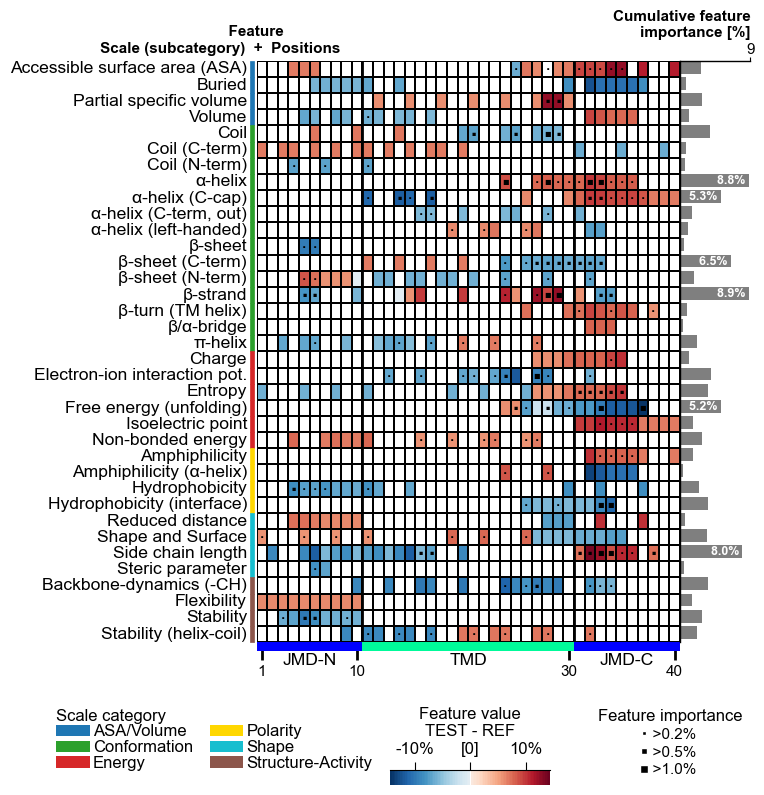

In [2]:
# Plot CPP feature map at group-level (as originally introduced without feature importance bars on top) 
cpp_plot = aa.CPPPlot()
aa.plot_settings(font_scale=0.7, weight_bold=False)
cpp_plot.feature_map(df_feat=df_feat, add_imp_bar_top=False)
plt.show()

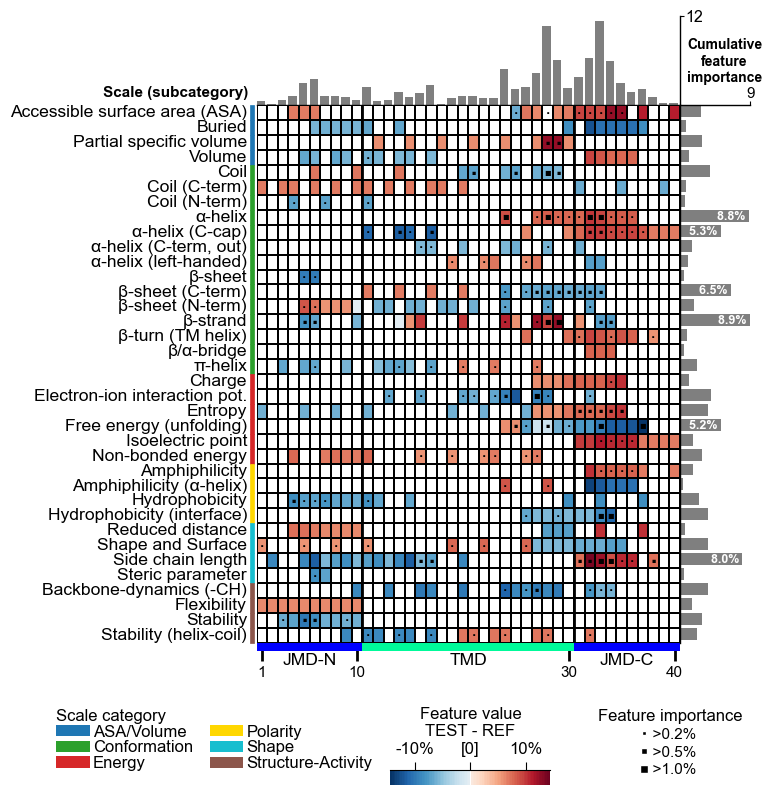

In [3]:
# Plot CPP feature map (v1.0.2+: with importance bars on top)
aa.plot_settings(font_scale=0.7, weight_bold=False)
cpp_plot.feature_map(df_feat=df_feat)
plt.show()

You can select a subset of features by filtering ``df_feat``: 

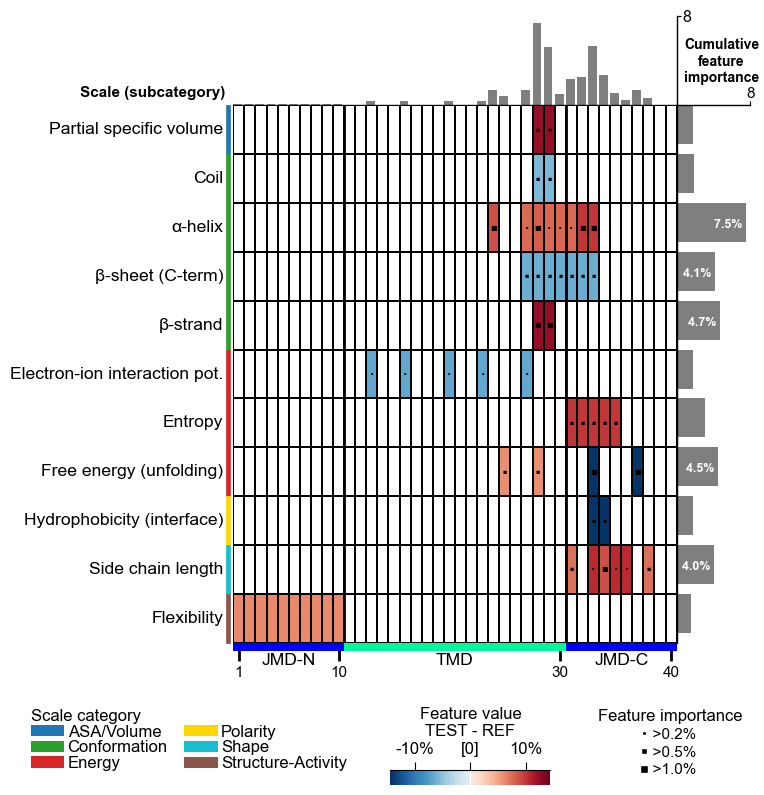

In [4]:
# Plot top 15 features
df_top15 = df_feat.head(15)
cpp_plot.feature_map(df_feat=df_top15)
plt.show()

Adjust the scale classification level (y-axis) using the ``col_cat`` parameter. Choose from the 'category', 'subcategory' (default), and 'scale_name' columns from the ``df_feat``:

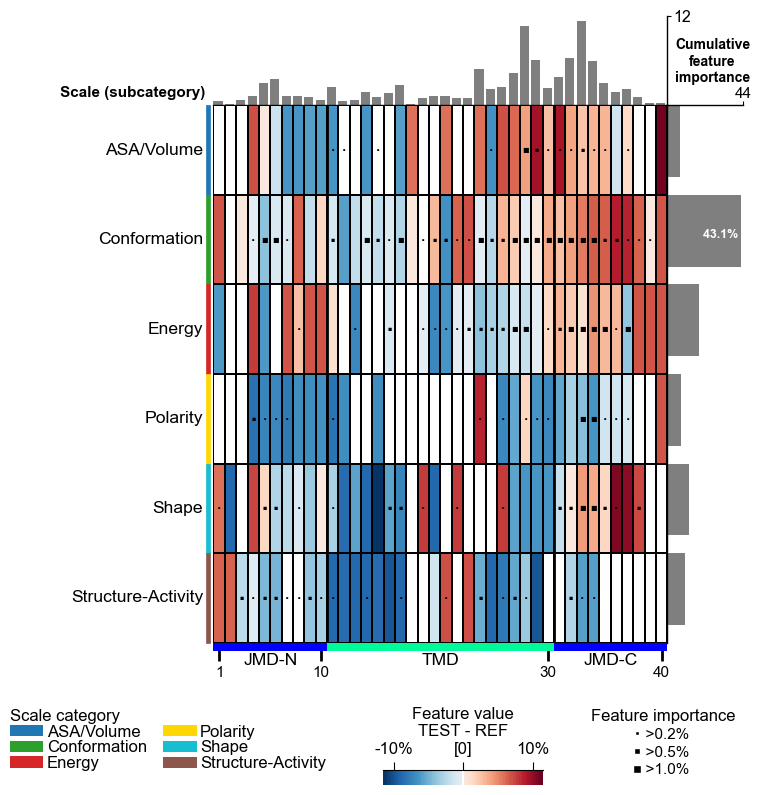

In [5]:
# Show feature map with scales classified by categories
cpp_plot.feature_map(df_feat=df_feat, col_cat="category")
plt.show()

The numerical value shown in the feature map can be adjusted by the ``col_val`` parameter, which specifies one of the following ``df_feat`` columns: 'mean_dif' (default), 'abs_mean_dif', 'abs_auc', or 'feat_importance':  

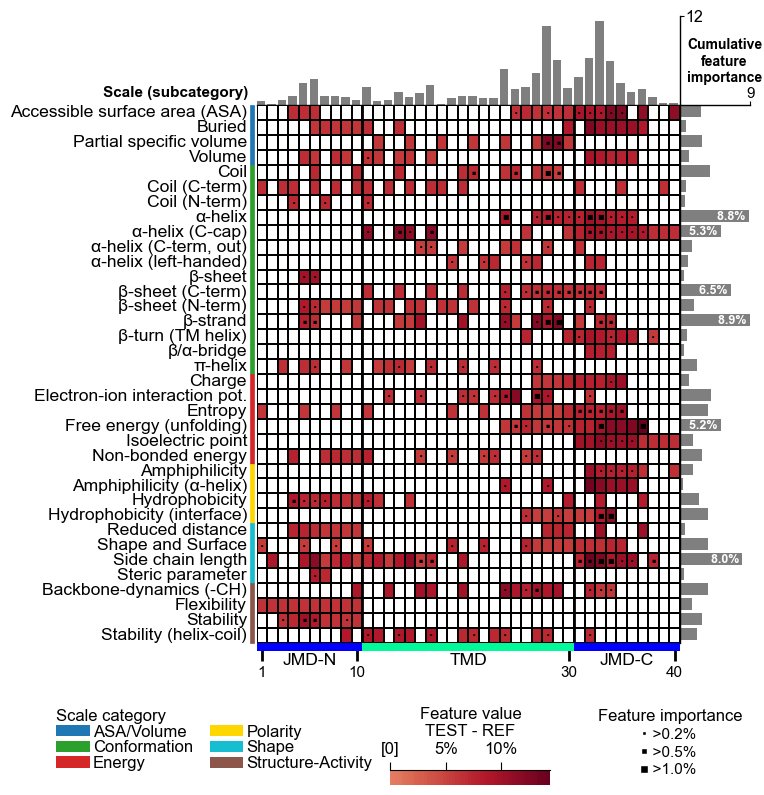

In [6]:
# Show feature map with absolute feature value difference
cpp_plot.feature_map(df_feat=df_feat, col_val="abs_mean_dif")
plt.show()

Adjust the names of the test and reference datasets using the ``name_test`` (default='TEST') and ``name_ref`` (default='REF') parameters:

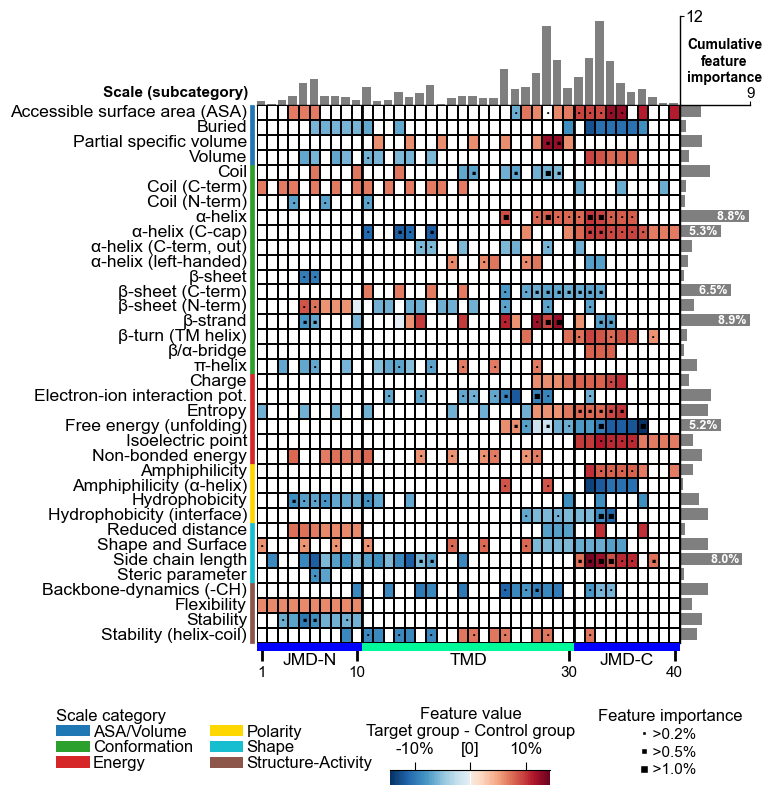

In [7]:
# Adjust dataset names shown in colorbar 
cpp_plot.feature_map(df_feat=df_feat, name_test="Target group", name_ref="Control group")
plt.show()

To visualize a subset of features, adjust the ``figsize`` (default=(8, 8)). Change the annotation threshold for the cumulative feature importance (right bar chart) using the ``imp_bar_th`` parameter and the respective fontsize using the ``fontsize_imp_bar`` (default=9):

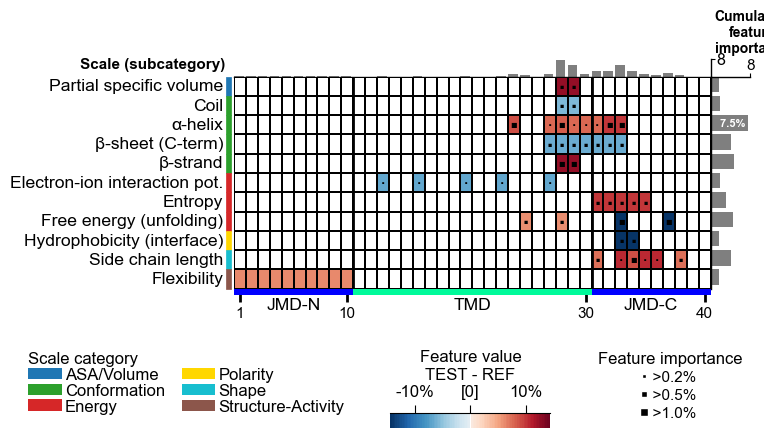

In [8]:
# Show only top 15 features
df_top15 = df_feat.head(15)
cpp_plot.feature_map(df_feat=df_top15, figsize=(8, 4),
                     imp_bar_th=7, fontsize_imp_bar=8)
plt.show()

You can adjust the ``start`` position and the ``tmd_len`` (default=20) by providing them as parameters. Change the length of the ``jmd_n`` and ``jmd_c`` using the ``CPPPlot`` object.

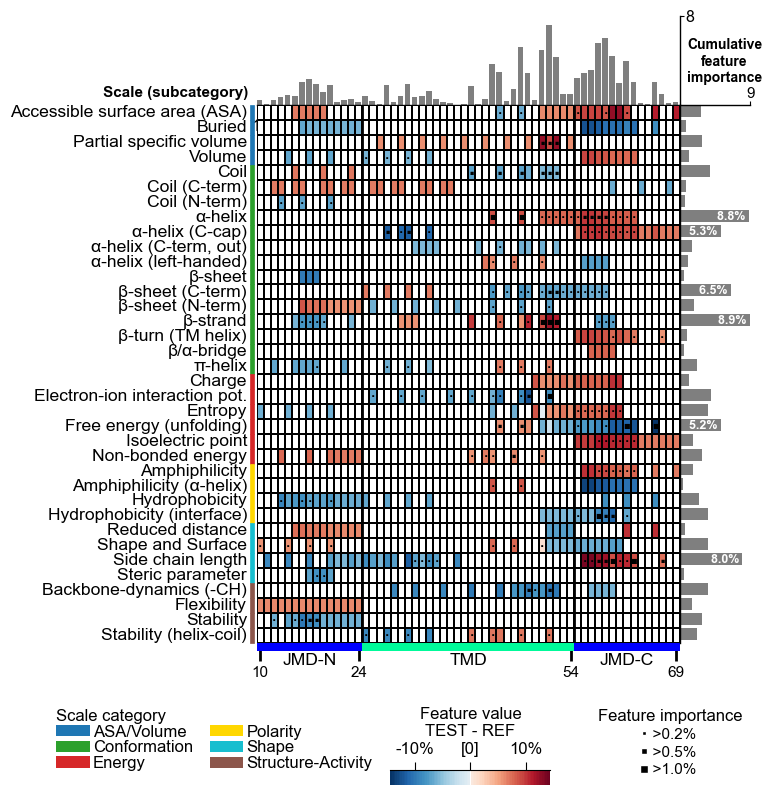

In [9]:
# Start at residue position 10 and adjust the length each part
cpp_plot = aa.CPPPlot(jmd_n_len=15, jmd_c_len=15)
cpp_plot.feature_map(df_feat=df_feat, start=10, tmd_len=30)
plt.show()

**CPP Analysis (sample-level)**

You can visualize how the general feature value difference is translated onto the sequence of a specific sample. To this end, you need to provide the corresponding sequence parameters: ``jmd_n_seq``, ``tmd_seq``, and ``jmd_c_seq``:

Sequence parts of first sample
FAEDVGSNKG AIIGLMVGGVVIATVIVITLVML KKKQYTSIHH


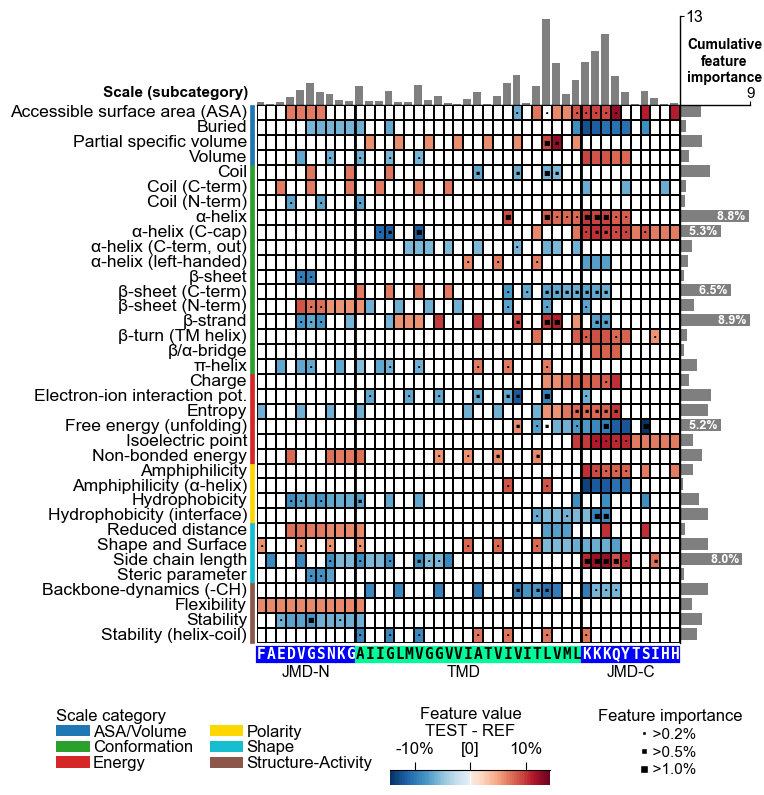

In [10]:
# Get sequence parts of first sample
cpp_plot = aa.CPPPlot()
jmd_n_seq, tmd_seq, jmd_c_seq = df_seq.loc[0, ["jmd_n", "tmd", "jmd_c"]]
args_seq = dict(jmd_n_seq=jmd_n_seq, tmd_seq=tmd_seq, jmd_c_seq=jmd_c_seq)
print("Sequence parts of first sample")
print(jmd_n_seq, tmd_seq, jmd_c_seq)

# Plot CPP profile for first sample
cpp_plot.feature_map(df_feat=df_feat, **args_seq)
plt.show()

You can customize the following color parameters: ``tmd_color`` (default='mediumspringgreen'), ``jmd_color`` (default='blue'), ``tmd_seq_color`` (default='black'), and ``jmd_seq_color`` (default='white'):

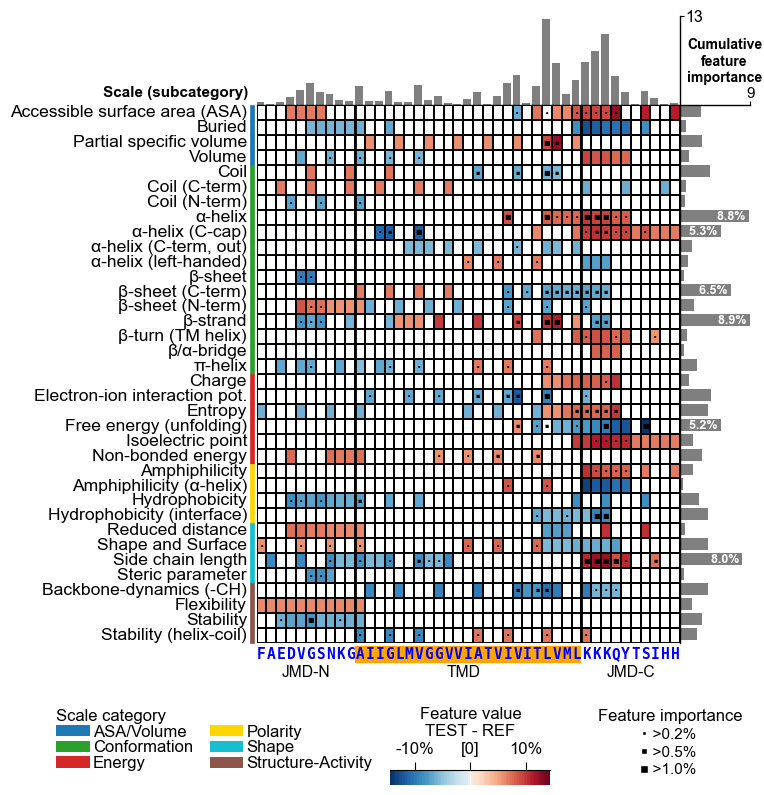

In [11]:
# Change default TMD-JMD colors
cpp_plot.feature_map(df_feat=df_feat, **args_seq, tmd_color="orange", jmd_color="white", tmd_seq_color="blue", jmd_seq_color="blue")
plt.show()

The fontsize of the sequence is optimized automatically. Set ``verbose=True`` to see the optimized size. You can set it manually using the ``seq_size`` parameter:

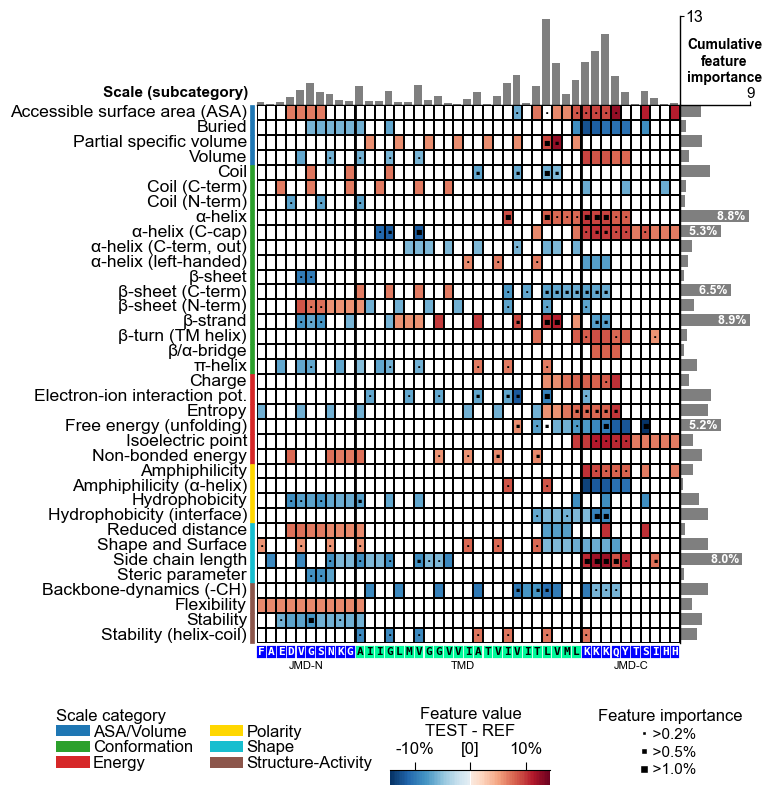

In [12]:
# Change sequence size manually
cpp_plot.feature_map(df_feat=df_feat, **args_seq, seq_size=8)
plt.show()

This might result in suboptimal spacing among sequence characters. Adjust the font size of the part labels ('JMD-N', 'TMD', 'JMD-C') using ``fontsize_tmd_jmd``, which is set by default to the optimized sequence size. Change its weight using ``weight_tmd_jmd`` (default='normal') 

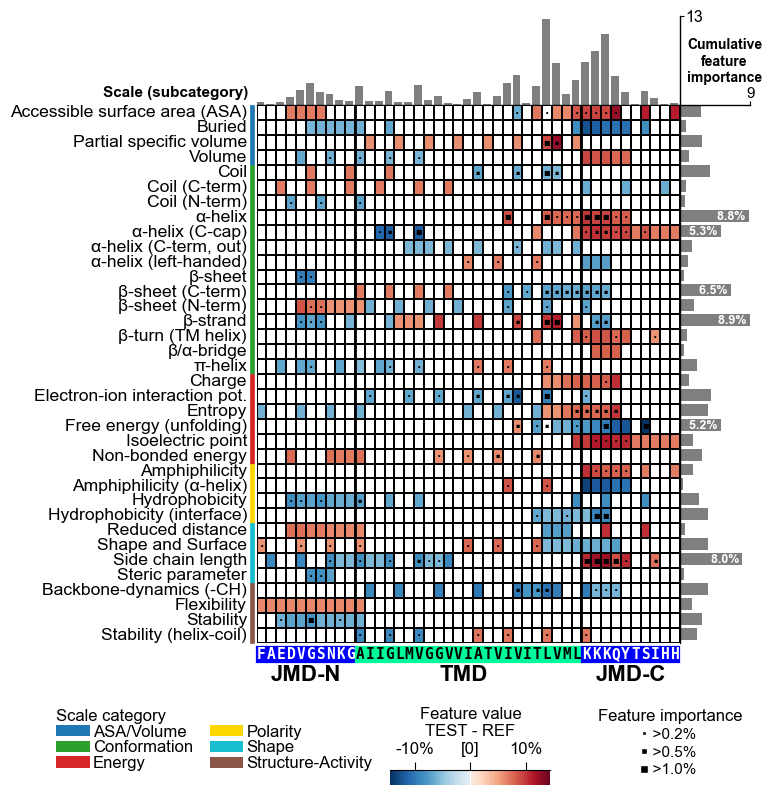

In [13]:
# Adjust the fontsize of the TMD-JMD characters
cpp_plot.feature_map(df_feat=df_feat, **args_seq, fontsize_tmd_jmd=16, weight_tmd_jmd="bold")
plt.show()

Display the xtick positions in addition to the sequence by setting ``add_xticks_pos=True`` (default=False):

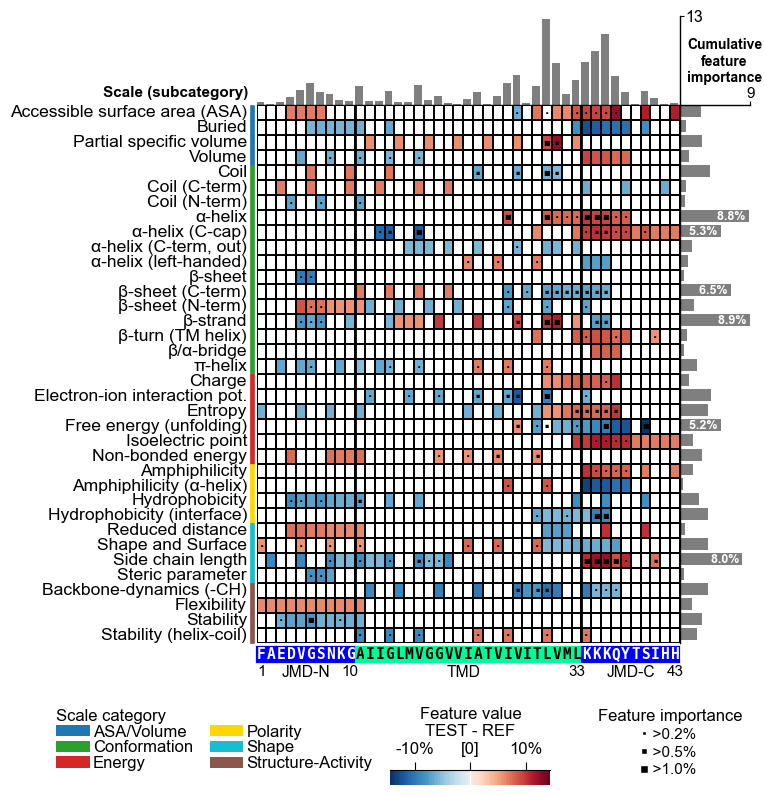

In [14]:
# Add the xticks indicating the sequence positions
cpp_plot.feature_map(df_feat=df_feat, **args_seq, add_xticks_pos=True)
plt.show()

**CPP Analysis**

Use ``fontsize_labels`` (default=12) to change the fontsize of the scale category legend and the colorbar:

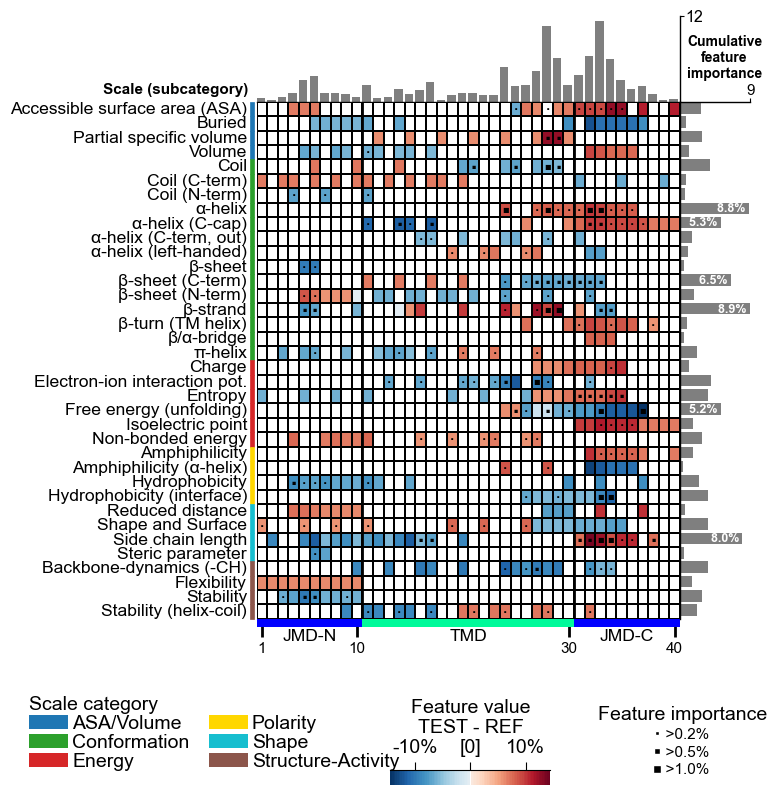

In [15]:
# Modify label size of legends and colorbar
cpp_plot.feature_map(df_feat=df_feat, fontsize_labels=14)
plt.show()

Change the fontsize of the titles (feature information on upper part of feature map) using ``fontsize_titles`` (default=11): 

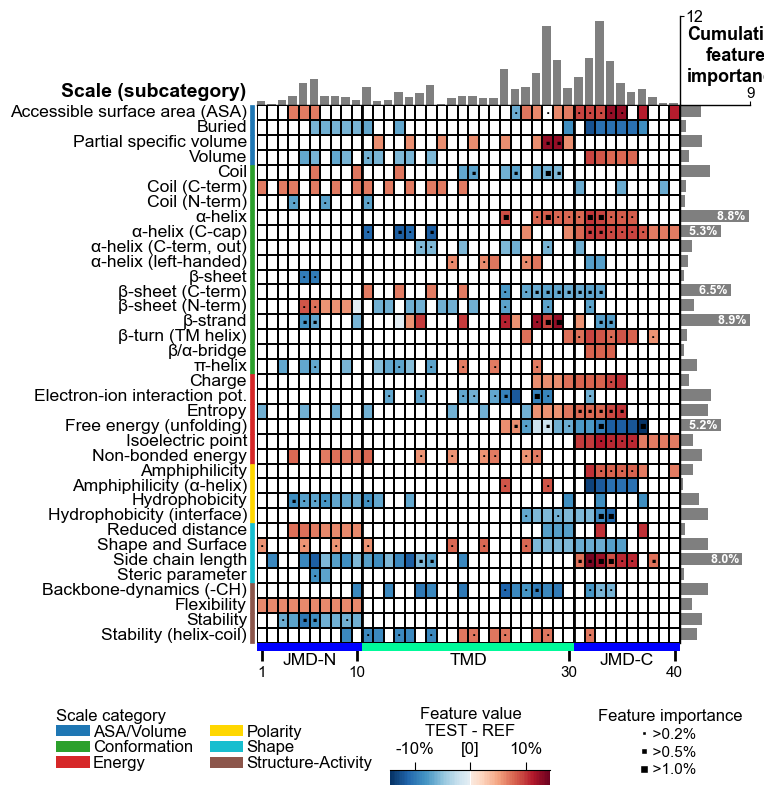

In [16]:
# Modify fontsize feature titles
cpp_plot.feature_map(df_feat=df_feat, fontsize_titles=14)
plt.show()

The fontsize of the feature importance percentages (excluding color bar) can be changed using the ``fontsize_annotations`` (default=11) parameter:

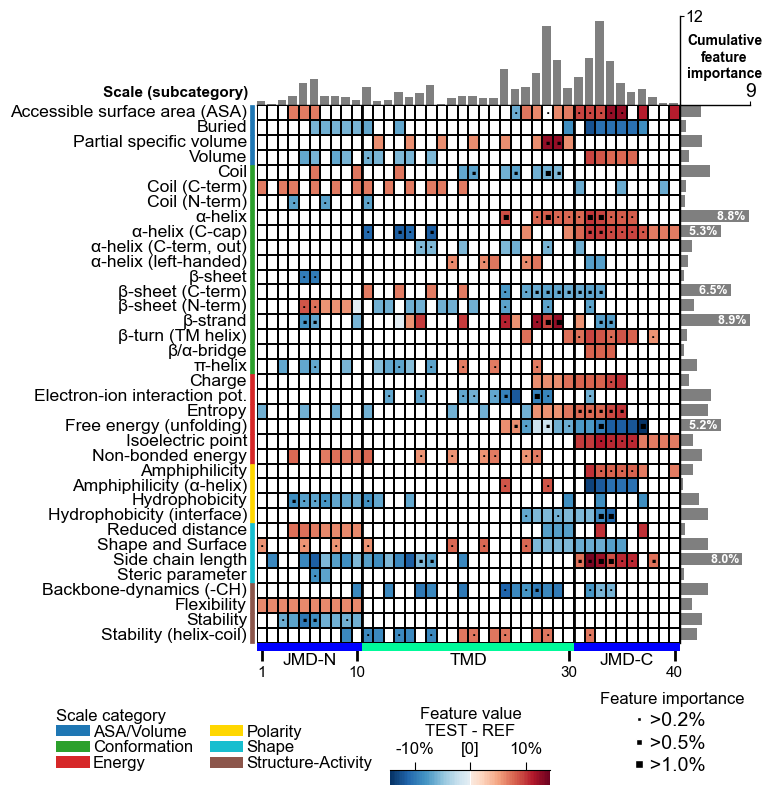

In [17]:
# Modify fontsize feature importance annotations
cpp_plot.feature_map(df_feat=df_feat, fontsize_annotations=14)
plt.show()

Adjust the feature map grid using the ``grid_linewidth`` (default=0.01) and ``grid_linecolor`` (set by default based on ``facecolor_dark``) parameters:

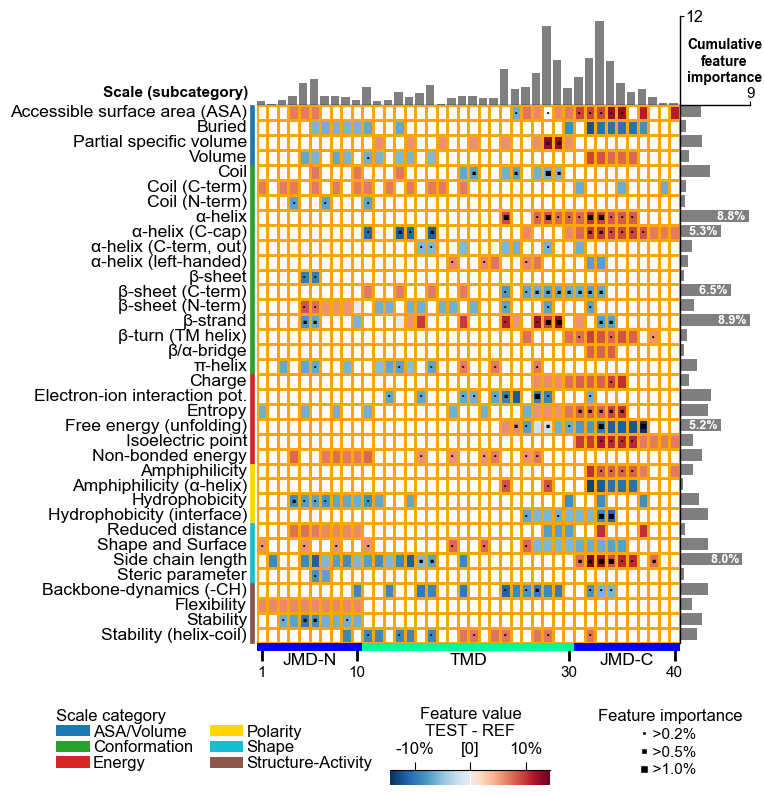

In [18]:
# Adjust feature map grid
cpp_plot.feature_map(df_feat=df_feat, grid_linewidth=1, grid_linecolor="orange")
plt.show()

The TMD part borders are highlighted by an extra line, which width can be customized by ``border_linewidth`` (default=2):

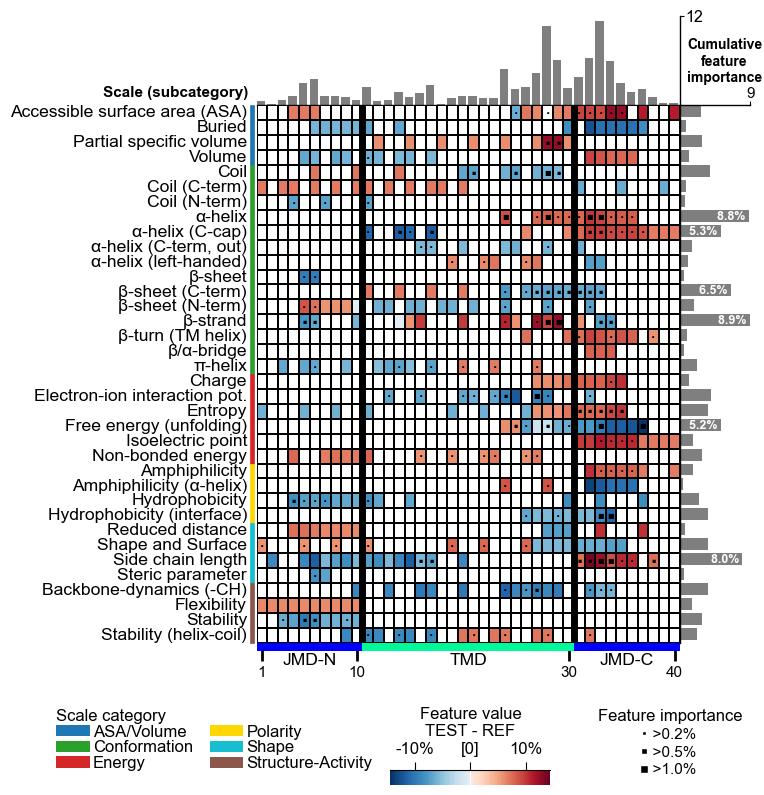

In [19]:
# Increase width of TMD border
cpp_plot.feature_map(df_feat=df_feat, border_linewidth=5)
plt.show()

The background is set automatically basd on ``shap_plot``. You can set it to black by ``facecolor_dark=True``: 

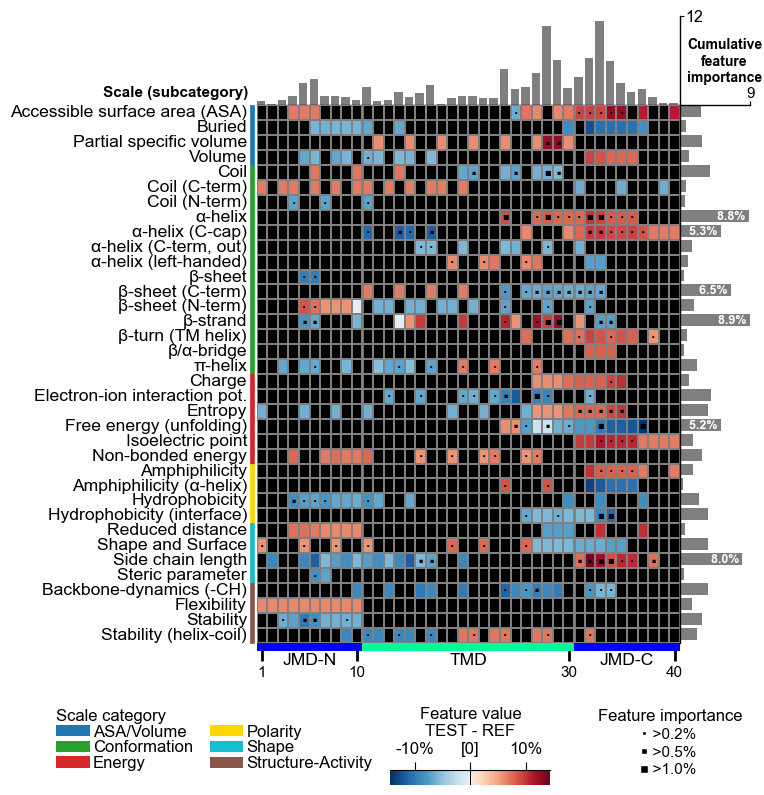

In [20]:
# Set background to black
cpp_plot.feature_map(df_feat=df_feat, facecolor_dark=True)
plt.show()

Adjust the lower and upper end of the colormap using the ``vmin`` and ``vmax`` parameters:

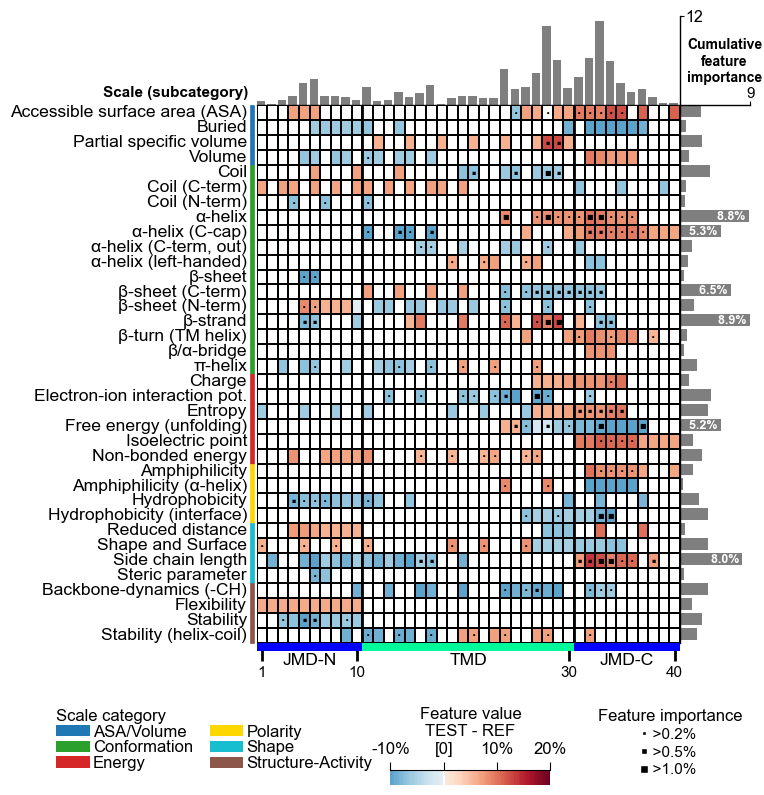

In [21]:
# Change minimum and maximum values
cpp_plot.feature_map(df_feat=df_feat, vmin=-10, vmax=20)
plt.show()

You can provide any colormap from [Matplotlib Colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html) using the ``cmap`` parameter. The number of discrete steps can be adjusted by ``cmap_n_colors`` (default=101): 

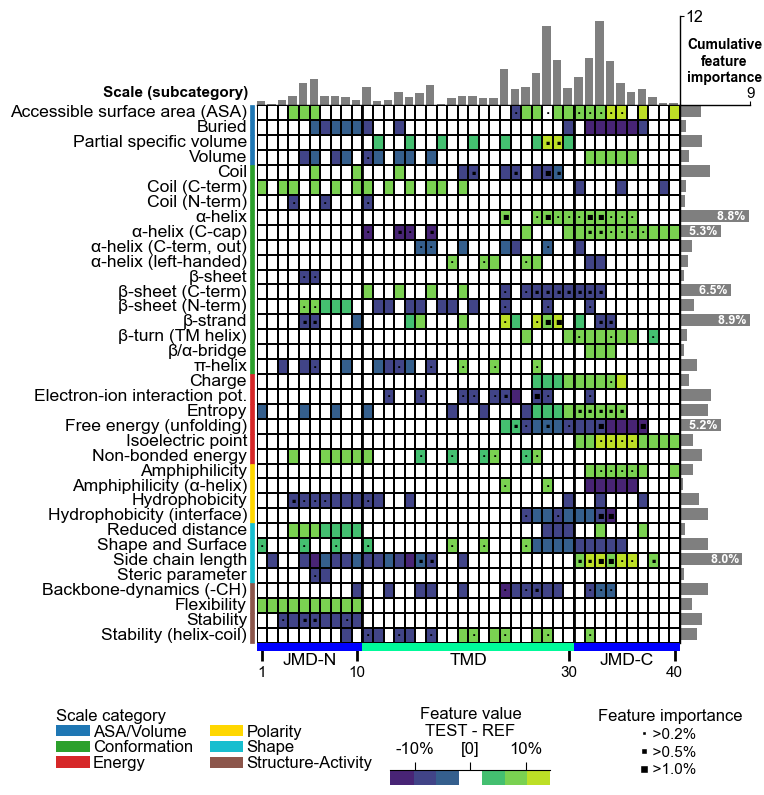

In [22]:
# Use matplotlib color map with 7 color steps
cpp_plot.feature_map(df_feat=df_feat, cmap="viridis", cmap_n_colors=7)
plt.show()

Customize the colorbar using ``cbar_kws``. You can adjust its position (x-axis, y-axis), width, and height by ``cbar_xywh`` (default=(0.7, None, 0.2, None)), where default values are adopted if ``None`` is provided. The position of the feature importance legend is set by the ``legend_imp_xy`` parameter relative to the color bar:

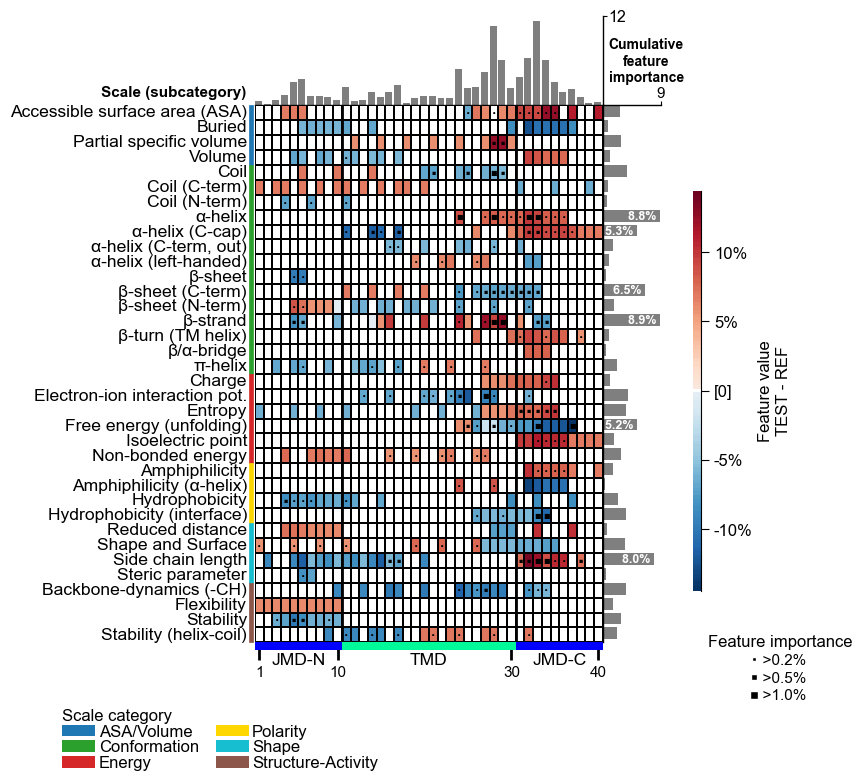

In [23]:
# Change colorbar title, position, width and height
cbar_kws = dict(orientation="vertical")
fig, ax = cpp_plot.feature_map(df_feat=df_feat, cbar_kws=cbar_kws,
                               cbar_xywh=(0.88, 0.25, 0.01, 0.5),
                               legend_imp_xy=(1, -0.3))
# Plot must be adjusted by plt.subplots_adjust and not by plt.tight_layout
plt.subplots_adjust(right=0.84)
plt.show()

Change the thresholds of the feature importance to be highlighted using the ``imp_ths`` (default=(0.2, 0.5, 1). The respective marker size can be adjusted using the ``imp_marker_sizes`` (default=(3, 5, 8)) parameter:

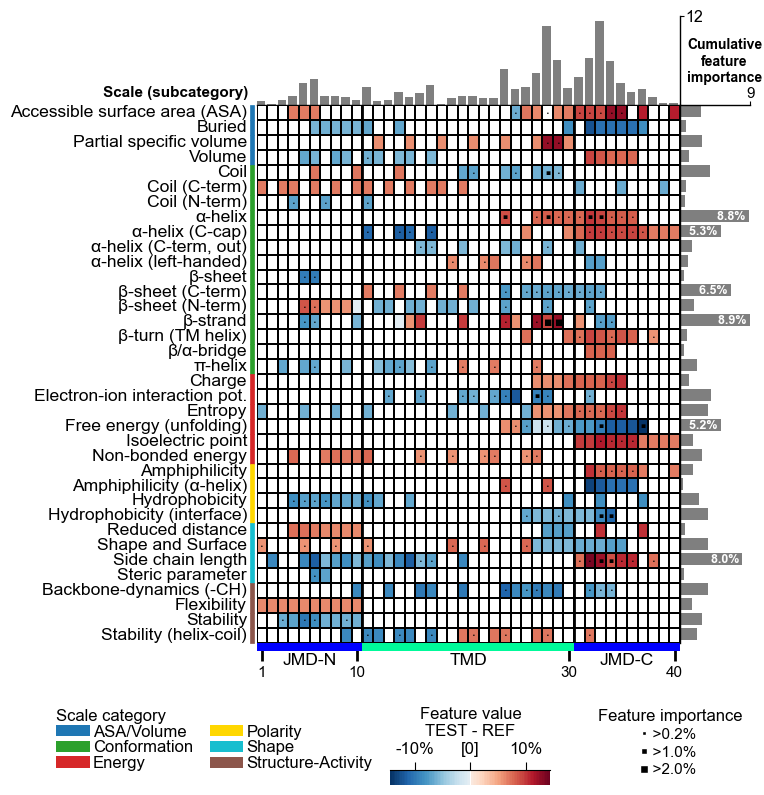

In [24]:
# Change threshold for highlighting feature importance
cpp_plot.feature_map(df_feat=df_feat, 
                     imp_ths=(0.2, 1, 2),
                     imp_marker_sizes=(2, 6, 10))
plt.show()

Adjust the scale legend by the ``legend_kws`` parameter and its position using ``legend_xy`` (default=(-0.1, -0.01)):

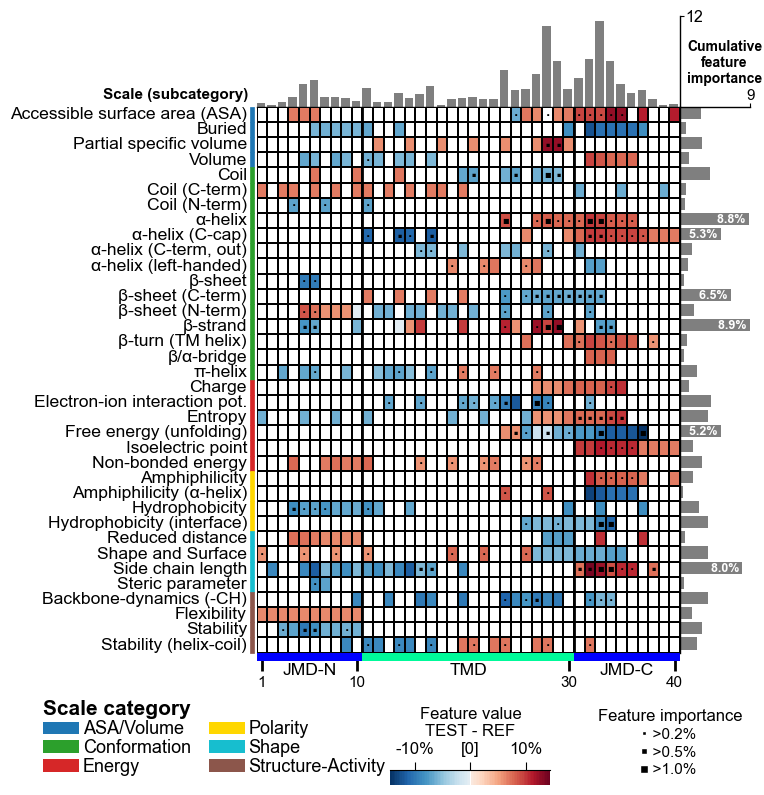

In [25]:
# Adjust legend, colors can be changed by 'dict_color' 
legend_kws = dict(fontsize=13, fontsize_title=15, weight_title="bold")
cpp_plot.feature_map(df_feat=df_feat, legend_kws=legend_kws, legend_xy=(None, 0.05))
plt.show()

Following x-tick parameters can be adjusted: xtick_size (default=11.0), xtick_width (default=2.0), and xtick_length (default=5.0):

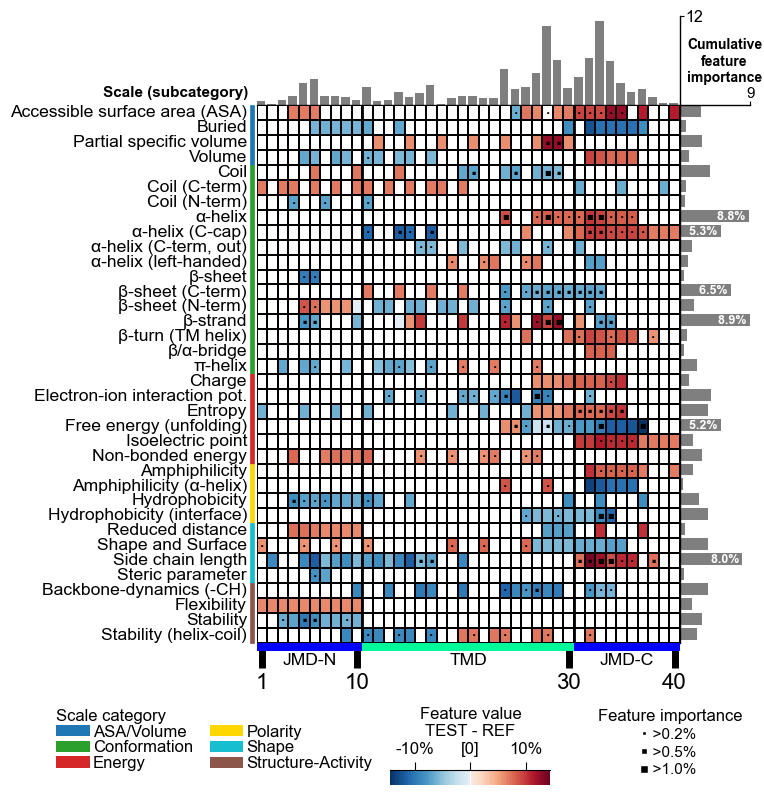

In [26]:
# Adjust x-ticks 
cpp_plot.feature_map(df_feat=df_feat, xtick_size=16, xtick_width=5, xtick_length=10)
plt.show()

X-ticks can be removed setting ``xtick_size=0``: 

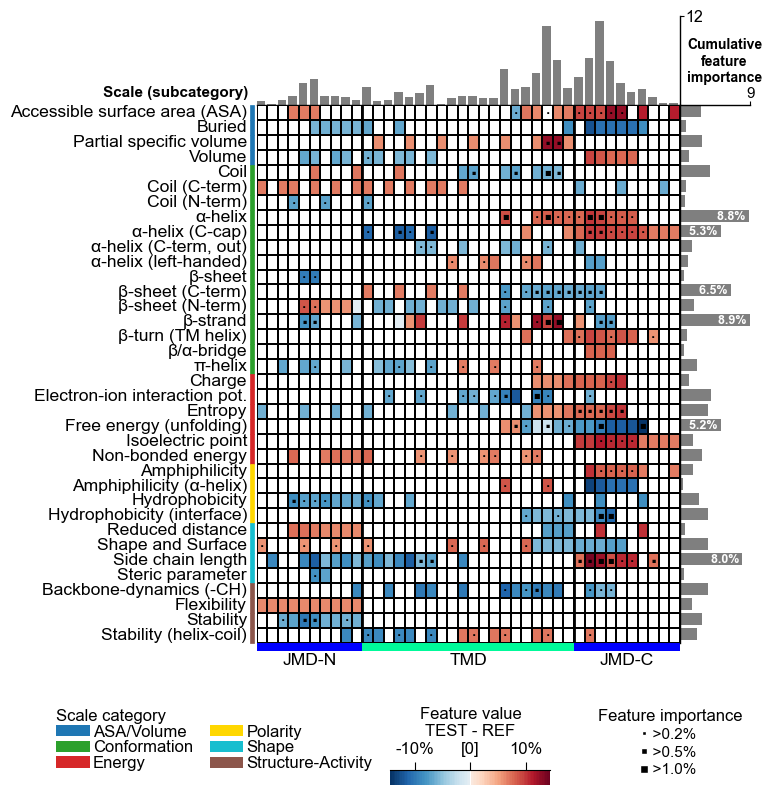

In [27]:
# Remove x-ticks
cpp_plot.feature_map(df_feat=df_feat, xtick_size=0)
plt.show()

**CPP Analysis (sample-level)**

To visualize the sample-specific feature value difference, we create the feature matrix for the DOM_GSEC example dataset (see [Breimann25a]_) using the ``SequenceFeature().feature_matrix()`` method:

In [28]:
# Create feature matrix
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

We now focus on a single sample, the Amyloid Precursor Protein (APP, UniProt ``P05067``) — the prototypical γ-secretase substrate and first entry of the ``DOM_GSEC`` dataset. Using the ``ShapModel``, we add its sample-specific feature value difference (``mean_dif_'name'``) to ``df_feat`` by passing ``sample_positions`` and ``names``:

In [29]:
# Add the sample-specific feature value difference for APP (sample 0) vs the reference set
labels = df_seq["label"].to_list()
sm = aa.ShapModel()

df_feat = sm.add_sample_mean_dif(X, labels=labels, df_feat=df_feat, sample_positions=0, names="APP")
aa.display_df(df_feat, n_rows=5, n_cols=15, show_shape=True)

DataFrame shape: (150, 16)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...,11)-LIFS790102",Conformation,β-strand,β-strand,"Conformational ...n-Sander, 1979)",0.189000,0.125674,0.125674,0.183876,0.218813,0.000001,0.000039,"28,29",4.729200,4.776785
2,"TMD_C_JMD_C-Seg...2,3)-CHOP780212",Conformation,β-sheet (C-term),β-turn (1st residue),"Frequency of th...-Fasman, 1978b)",0.199000,0.065983,-0.065983,0.087814,0.105835,0.000000,0.000016,"27,28,29,30,31,32,33",4.106000,5.236574
3,"TMD_C_JMD_C-Seg...3,4)-HUTJ700102",Energy,Entropy,Entropy,"Absolute entrop...Hutchens, 1970)",0.229000,0.098224,0.098224,0.106865,0.124608,0.000000,0.000001,"31,32,33,34,35",3.111200,3.109955
4,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
5,"TMD_C_JMD_C-Pat...4,8)-JANJ790102",Energy,Free energy (unfolding),Transfer free e...(TFE) to inside,"Transfer free e...y (Janin, 1979)",0.187000,0.144354,-0.144354,0.181777,0.233103,0.000001,0.000049,"33,37",2.833600,3.640617


**Option 1 — APP's feature value difference.** Provide APP's ``mean_dif_APP`` column in ``col_val`` together with the sequence parameters to see how the feature value difference maps onto APP's sequence (``shap_plot=False``). The bars and markers here still use the default ``feat_importance`` column, which is the **dataset-wide (global)** feature importance — *not* APP-specific. Options 2 and 3 below make the bars APP-specific.

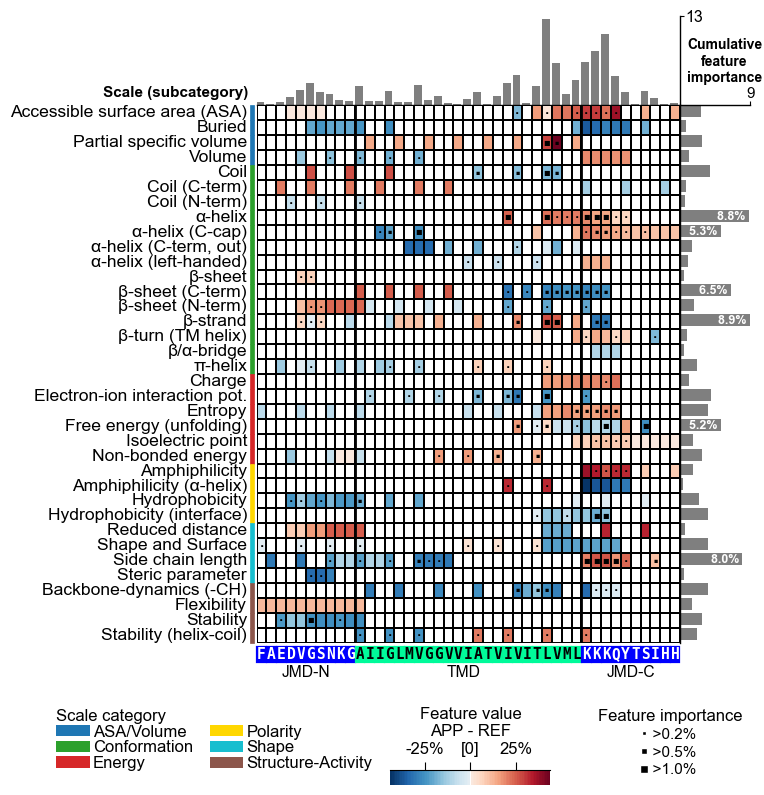

In [30]:
# Option 1: APP feature value difference (heatmap = mean_dif_APP; bars = global feat_importance)
args_seq = dict(tmd_seq=tmd_seq, jmd_n_seq=jmd_n_seq, jmd_c_seq=jmd_c_seq)
cpp_plot.feature_map(df_feat=df_feat,
                     col_val="mean_dif_APP",
                     name_test="APP",
                     **args_seq)
plt.show()

**CPP-SHAP Analysis (sample-level).** To make the bars APP-specific, fit the ``ShapModel`` explainer and add APP's signed feature impact (``feat_impact_APP``) to ``df_feat`` — the per-sample SHapley Additive exPlanations (SHAP) [Lundberg20]_ attribution. We keep ``drop=False`` so the group-level ``feat_importance`` column stays available for comparison:

In [31]:
# Fit SHAP explainer and add APP's per-sample feature impact (keep the global feat_importance)
sm.fit(X, labels=labels)
df_feat = sm.add_feat_impact(df_feat=df_feat, sample_positions=0, names="APP", drop=False)

**Option 2 — feature value difference + APP's own importance.** A sample's *importance* is the **magnitude** of its impact, ``abs(feat_impact_APP)``. Deriving it and passing it via ``col_imp`` (with ``shap_plot=False``) shows APP's **own** cumulative importance — the correct sample-level counterpart to Option 1's global ``feat_importance``. This is the recommended way to show a single sample's importance when you do not want the signed bars: *impact → importance*.

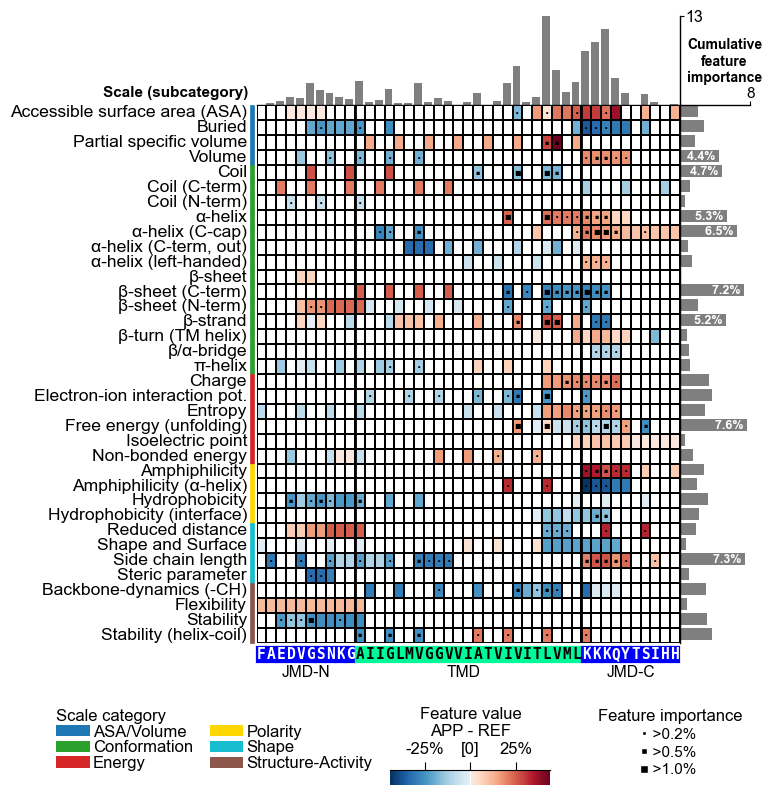

In [32]:
# Option 2: a sample's importance is its absolute (unsigned) feature impact
df_feat["feat_importance_APP"] = df_feat["feat_impact_APP"].abs()
cpp_plot.feature_map(df_feat=df_feat,
                     col_val="mean_dif_APP",
                     col_imp="feat_importance_APP",
                     name_test="APP",
                     **args_seq)
plt.show()

**Option 3 — feature value difference + signed SHAP impact.** Setting ``shap_plot=True`` with ``col_imp="feat_impact_APP"`` keeps the same ``mean_dif_APP`` heatmap but stacks the **signed** impact per feature in the bars (positive in red, negative in blue); the markers encode the absolute impact (magnitude):

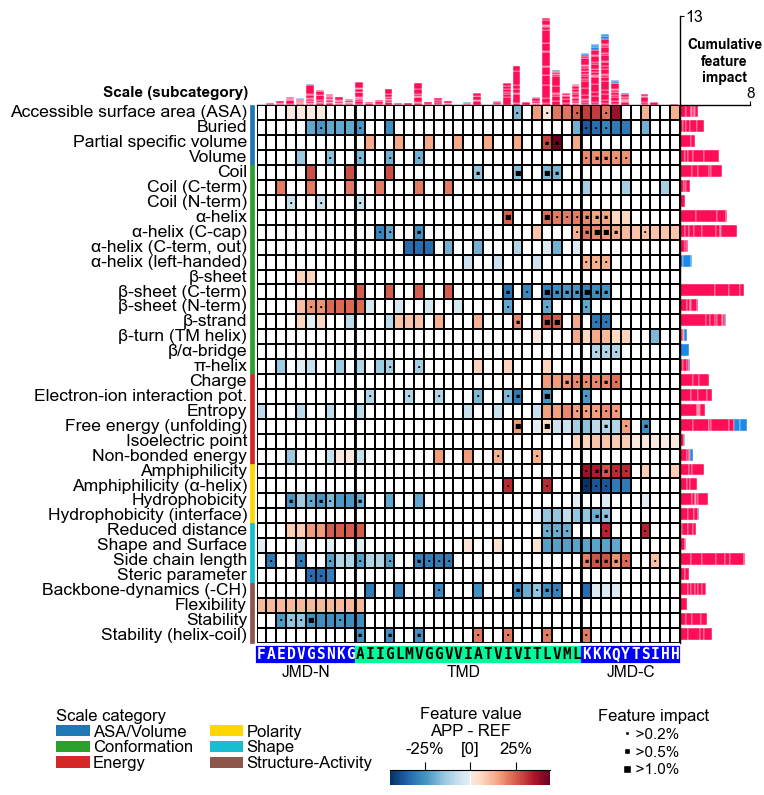

In [33]:
# Option 3: signed SHAP feature impact (stacked +/- bars), mean-difference heatmap
cpp_plot.feature_map(df_feat=df_feat,
                     shap_plot=True,
                     col_val="mean_dif_APP",
                     col_imp="feat_impact_APP",
                     name_test="APP",
                     **args_seq)
plt.show()

As a further variant, pass a ``feat_impact_'name'`` column in ``col_val`` to show APP's SHAP feature impact directly in the **heatmap** (diverging SHAP colormap). In this case the cumulative-impact bars are switched off, since the impact is already encoded in the cells:

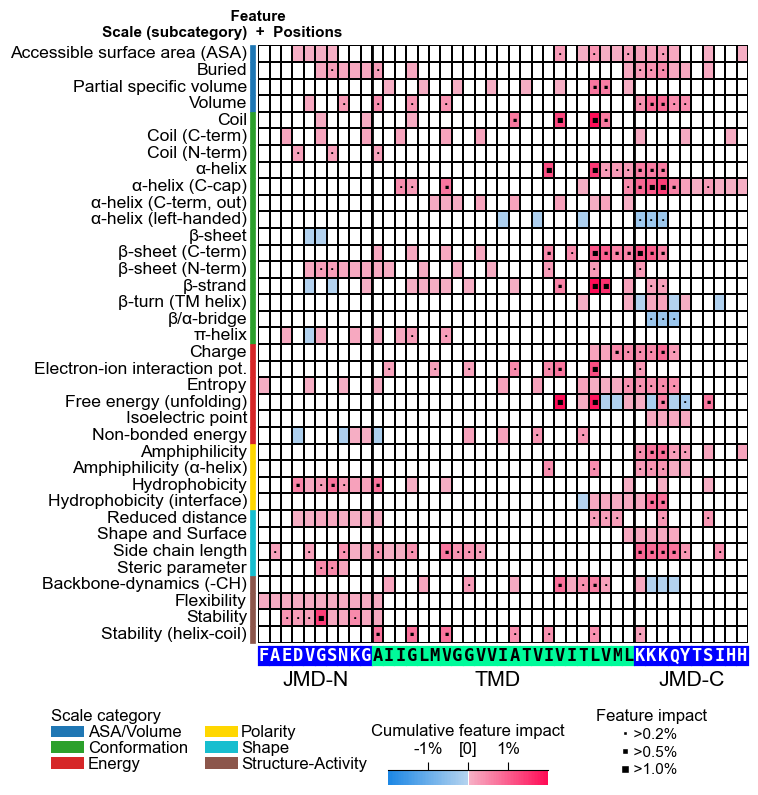

In [34]:
# Plot CPP-SHAP feature map for APP with the impact shown in the heatmap (bars off)
cpp_plot.feature_map(df_feat=df_feat,
                     shap_plot=True,
                     col_val="feat_impact_APP",
                     col_imp="feat_impact_APP",
                     name_test="APP",
                     **args_seq)
plt.show()